# TBD Phase 2: Performance & Computing Models

## Introduction
In this lab, you will compare the performance and computing models of four popular data processing engines: **Polars, Pandas, DuckDB, and PySpark**.

You will explore:
- **Performance**: Single-node processing speed, parallel execution, and memory usage.
- **Scalability**: How performance changes with the number of cores (single-node) and executors (cluster).
- **Computing Models**: Out-of-core vs. In-memory processing, and Eager vs. Lazy execution.

### Engine Capabilities
The following table summarizes the key capabilities of the engines we will be testing. Use this as a reference.

| Engine | Query Optimizer | Distributed | Arrow-backed | Out-of-Core | Parallel | APIs | GPU Support |
|---|---|---|---|---|--|---|---|
| **Pandas** | ❌ | ❌ | optional ≥ 2.0 | ❌ | ❌ | DataFrame | ❌ |
| **Polars** | ✅ | ❌ | ✅ | ✅ | ✅ | DataFrame | ✅ (opt) |
| **PySpark** | ✅ | ✅ | Pandas UDF/IO | ✅ | ✅ | SQL, DataFrame | ❌ (no GPU) |
| **DuckDB** | ✅ | ❌ | ✅ | ✅ | ❌ | SQL, Relational API | ❌ |

## Prerequisites
Ensure you have the necessary libraries installed.

In [1]:
%pip install polars pandas duckdb pyspark faker deltalake memory_profiler pyarrow

  Using cached polars-1.37.1-py3-none-any.whl (805 kB)
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
  Using cached duckdb-1.4.4-cp310-cp310-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl (20.4 MB)
  Using cached pyspark-4.1.1.tar.gz (455.4 MB)
  Preparing metadata (setup.py) ... done
  Using cached faker-40.1.2-py3-none-any.whl (2.0 MB)
  Using cached deltalake-1.4.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (39.6 MB)
  Using cached memory_profiler-0.61.0-py3-none-any.whl (31 kB)
  Using cached pyarrow-23.0.0-cp310-cp310-manylinux_2_28_x86_64.whl (47.5 MB)
  Using cached polars_runtime_32-1.37.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (45.1 MB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
  Using cached py4j-0.10.9.9-py2.py3-none-any.whl (203 kB)
  Using cached arro3_core-0.6.5-cp310-cp310-man

In [ ]:
import os

os.environ["POLARS_MAX_THREADS"] = "1"

In [ ]:
import os

os._exit(0)

In [2]:
import polars as pl
import pandas as pd
import duckdb
from pyspark.sql import SparkSession
from faker import Faker
import numpy as np
import os
import time
import psutil
from memory_profiler import memory_usage

# Initialize Spark (Single Node)
spark = (
    SparkSession.builder.appName("BigDataLab2")
    .master("local[1]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

duckdb.sql(f"PRAGMA threads=1")

print(f"Spark: {spark.sparkContext.master}")
print(f"Polars: {pl.thread_pool_size()}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/27 21:49:44 WARN Utils: Your hostname, LAPTOP-O876QN6E, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/27 21:49:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/27 21:49:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: local[1]
Polars: 8


## Part 1: Data Generation

We will generate a synthetic dataset simulating social media posts with a rich schema.

**Schema**:
- `post_id` (String): Unique identifier.
- `user_id` (Integer): User identifier.
- `timestamp` (DateTime): Time of post.
- `content` (String): Text content.
- `likes` (Integer): Number of likes.
- `views` (Integer): Number of views.
- `category` (String): Post category.
- `tags` (List[String]): Hashtags.
- `location` (String): User location.
- `device` (String): Device used (Mobile, Web, etc.).
- `latency` (Float): Network latency.
- `error_rate` (Float): Error rate during upload.

In [ ]:
import polars as pl
import pandas as pd
import duckdb
from pyspark.sql import SparkSession
from faker import Faker
import numpy as np
import os
import time
import psutil
from memory_profiler import memory_usage


def generate_data(num_records=1_000_000, output_path="social_media_data.parquet"):
    fake = Faker()

    print(f"Generating {num_records} records...")

    # Generate data using numpy for speed where possible
    data = {
        "post_id": [fake.uuid4() for _ in range(num_records)],
        "user_id": np.random.randint(1, 100_000, num_records),
        "timestamp": pd.date_range(start="2023-01-01", periods=num_records, freq="s")
        .to_numpy()
        .astype("datetime64[us]"),
        "likes": np.random.randint(0, 10_000, num_records),
        "views": np.random.randint(0, 1_000_000, num_records),
        "category": np.random.choice(
            ["Tech", "Health", "Travel", "Food", "Fashion", "Politics", "Sports"],
            num_records,
        ),
        "tags": [
            np.random.choice(
                ["#viral", "#new", "#trending", "#hot", "#update"],
                size=np.random.randint(1, 4),
            ).tolist()
            for _ in range(num_records)
        ],
        "location": np.random.choice(
            ["USA", "UK", "DE", "PL", "FR", "JP", "BR"], num_records
        ),
        "device": np.random.choice(["Mobile", "Desktop", "Tablet"], num_records),
        "latency": np.random.uniform(10.0, 500.0, num_records),
        "error_rate": np.random.beta(1, 10, num_records),
        "content": [fake.sentence() for _ in range(min(num_records, 1000))]
        * (num_records // 1000 + 1),
    }

    users_count = 500_000
    users = {
        "user_id": np.arange(1, users_count + 1),
        "age": np.random.randint(18, 50, users_count),
        "nationality": np.random.choice(
            ["USA", "UK", "DE", "PL", "FR", "JP", "BR"], users_count
        ),
    }

    # Trim to exact size
    data["content"] = data["content"][:num_records]

    df = pd.DataFrame(data)

    print("Writing to Parquet...")
    df.to_parquet(output_path, engine="pyarrow")
    print(f"Data saved to {output_path}")

    df_users = pd.DataFrame(users)
    users_output_path = "users.parquet"
    df_users.to_parquet(users_output_path, engine="pyarrow")
    print(f"Users' data saved to {users_output_path}")


# Generate 5 million records
generate_data(num_records=15_000_000)

Generating 15000000 records...
Writing to Parquet...
Data saved to social_media_data.parquet
Users' data saved to users.parquet


## Part 2: Measuring Performance

### 2.1 Execution Time
Use `%time` or `%timeit` to measure execution time.

In [ ]:
# Example: Measuring time for all engines
print("--- Performance Benchmark Example ---")

# Pandas
print("Pandas Load Time:")
%time df_pd = pd.read_parquet("social_media_data.parquet")

# Polars
print("\nPolars Load Time:")
%time df_pl = pl.read_parquet("social_media_data.parquet")

# DuckDB
print("\nDuckDB Query Time:")
%time duckdb.sql("SELECT count(*) FROM 'social_media_data.parquet'").show()

# PySpark
print("\nSpark Load Time:")
%time df_spark = spark.read.parquet("social_media_data.parquet"); df_spark.count()


--- Performance Benchmark Example ---
Pandas Load Time:
CPU times: user 2.19 s, sys: 961 ms, total: 3.15 s
Wall time: 1.26 s

Polars Load Time:
CPU times: user 466 ms, sys: 154 ms, total: 620 ms
Wall time: 619 ms

DuckDB Query Time:
┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      5000000 │
└──────────────┘

CPU times: user 0 ns, sys: 1.48 ms, total: 1.48 ms
Wall time: 1.4 ms

Spark Load Time:
CPU times: user 6.08 ms, sys: 8.52 ms, total: 14.6 ms
Wall time: 1.71 s


5000000

## Part 3: Student Tasks

### Task 1: Performance & Scalability (Single Node)

**Goal**: Benchmark the engines and test how they scale with available CPU cores.

**Instructions**:
1.  **Define Queries**: Create 3 distinct queries of your own choice. They should cover:
    -   **Query A**: A simple aggregation (e.g., grouping by a categorical column and calculating means).
    -   **Query B**: A window function or more complex transformation.
    -   **Query C**: A join (e.g., self-join or join with a smaller generated table) with filtering.
2.  **Benchmark**: Implement these queries in **Pandas, Polars, DuckDB, and PySpark**.
    -   Measure **Execution Time** using `%time` or `time.time()`.
    -   Measure **Peak Memory** usage using `memory_profiler` (e.g., `memory_usage()`).
3.  **Scalability Test**: 
    -   Select **all engines** that support parallel execution on a single node (e.g., Polars, DuckDB).
    -   Run **all 3 queries** with different numbers of threads/cores (e.g., 1, 2, 4, 8).
    -   Plot the speedup for each query and engine.

**Tip**: 
-   Polars: [polars.thread_pool_size](https://docs.pola.rs/api/python/stable/reference/api/polars.thread_pool_size.html) Please also note that *Thread configuration in Polars requires process restart*
-   DuckDB: `PRAGMA threads=n`
-   Spark: `master="local[n]"`

In [ ]:
# Example: Measuring time for all engines
print("--- Reading users data ---")

# Pandas
print("Pandas Load Time:")
%time df_pd_users = pd.read_parquet("users.parquet")

# Polars
print("\nPolars Load Time:")
%time df_pl_users = pl.read_parquet("users.parquet")

# PySpark
print("\nSpark Load Time:")
%time df_spark_users = spark.read.parquet("users.parquet"); df_spark.count()

--- Reading users data ---
Pandas Load Time:
CPU times: user 18.3 ms, sys: 0 ns, total: 18.3 ms
Wall time: 9.68 ms

Polars Load Time:
CPU times: user 5.36 ms, sys: 2.77 ms, total: 8.13 ms
Wall time: 7.9 ms

Spark Load Time:
CPU times: user 578 μs, sys: 88 μs, total: 666 μs
Wall time: 129 ms


5000000

In [ ]:
def read_data():
    df_pd = pd.read_parquet("social_media_data.parquet")
    df_pl = pl.read_parquet("social_media_data.parquet")
    df_spark = spark.read.parquet("social_media_data.parquet")
    df_pd_users = pd.read_parquet("users.parquet")
    df_pl_users = pl.read_parquet("users.parquet")
    df_spark_users = spark.read.parquet("users.parquet")

**Query A**

Group by location, aggregate function - mean of likes

In [ ]:
from pyspark.sql import functions as fn


def query_A_pandas():
    return df_pd.groupby("location")["likes"].agg("mean").shape[0]


def query_A_polars():
    return df_pl.group_by("location").agg(pl.col("likes").mean()).height


def query_A_duckdb():
    return duckdb.sql(
        "SELECT COUNT(*) from (SELECT location, AVG(likes) FROM 'social_media_data.parquet' GROUP BY location)"
    ).fetchall()[0][0]


def query_A_spark():
    return df_spark.groupBy("location").agg(fn.avg("likes")).count()

**Query B**

Calculate rolling average likes for every post taking this post and two last posts of the same user (when there are less than 2 last post take 1 or 0). Then, filter posts where this average is > 5000.


In [ ]:
def query_B_pandas():
    df_sorted = df_pd.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

    g = df_sorted.groupby("user_id")["likes"]

    df_sorted["avg_last_3"] = df_sorted.groupby("user_id", group_keys=False)[
        "likes"
    ].apply(lambda s: s.rolling(3, min_periods=1).mean())

    return (df_sorted["avg_last_3"] > 5000).sum()


def query_B_polars():
    return (
        df_pl.sort(["user_id", "timestamp"])
        .with_columns(
            pl.col("likes")
            .rolling_mean(window_size=3, min_samples=1)
            .over("user_id")
            .alias("avg_last_3")
        )
        .filter(pl.col("avg_last_3") > 5000)
        .height
    )


def query_B_duckdb():
    return duckdb.sql(
        "SELECT COUNT(*) FROM (SELECT *, AVG(likes) OVER ("
        "PARTITION BY user_id "
        "ORDER BY timestamp "
        "ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS avg_last_3 "
        "FROM 'social_media_data.parquet') WHERE avg_last_3 > 5000"
    ).fetchall()[0][0]


df_spark.createOrReplaceTempView("posts")
df_spark_users.createOrReplaceTempView("users")


def query_B_spark():
    return spark.sql(
        """
        SELECT COUNT(*)
        FROM (
            SELECT
                *,
                AVG(likes) OVER (
                    PARTITION BY user_id
                    ORDER BY timestamp
                    ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
                ) AS avg_last_3
            FROM posts
        )
        WHERE avg_last_3 > 5000
    """
    ).collect()[0][0]

**Query C**

Join posts and users by user_id. Then, filter by age (>= 25).

In [ ]:
def query_C_pandas():
    return (
        df_pd.merge(df_pd_users, on="user_id", how="inner").query("age >= 25").shape[0]
    )


def query_C_polars():
    return (
        df_pl.join(df_pl_users, on="user_id", how="inner")
        .filter(pl.col("age") >= 25)
        .height
    )


def query_C_duckdb():
    return duckdb.sql(
        "SELECT COUNT(*) FROM (SELECT * FROM 'social_media_data.parquet' AS posts "
        "INNER JOIN 'users.parquet' AS users "
        "on posts.user_id=users.user_id where users.age >= 25)"
    ).fetchall()[0][0]


def query_C_spark():
    return (
        df_spark.join(df_spark_users, on="user_id", how="inner")
        .where("age >= 25")
        .count()
    )

Benchmark - time + memory peak

Funtion ```plot_results``` for speedup-thread plots

In [3]:
%pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 2.2 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 1.3 MB/s eta 0:00:0000:0100:010m
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 1.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 KB 1.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 1.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [8]:
import matplotlib.pyplot as plt


def plot_results(df_results):
    df_results["Threads"] = df_results["Threads"].astype(int)
    df_results["Time [s]"] = df_results["Time [s]"].astype(float)
    df_results["Speedup"] = df_results.groupby("Query")["Time [s]"].transform(
        lambda x: x.iloc[0] / x
    )
    plt.figure(figsize=(6, 4))

    for query, g in df_results.groupby("Query"):
        plt.plot(g["Threads"], g["Speedup"], marker="o", label=query)

    plt.xlabel("Threads")
    plt.ylabel("Speedup")
    plt.title("Speedup - thread plot")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
queries = {
    "A pandas": query_A_pandas,
    "A polars": query_A_polars,
    "A duckdb": query_A_duckdb,
    "A spark": query_A_spark,
    "B pandas": query_B_pandas,
    "B polars": query_B_polars,
    "B duckdb": query_B_duckdb,
    "B spark": query_B_spark,
    "C pandas": query_C_pandas,
    "C polars": query_C_polars,
    "C duckdb": query_C_duckdb,
    "C spark": query_C_spark,
}


def measure_time(query):
    start = time.perf_counter()
    result = query()
    elapsed = time.perf_counter() - start
    return elapsed


def measure_peak_memory(query):
    return memory_usage(query, max_usage=True)


def benchmark(queries):
    results = []
    for query_name, query_fn in queries.items():

        # three query execution - first warm-up
        query_fn()

        # second for time benchmark
        t = measure_time(query_fn)

        # third for memory peak benchmark
        m = measure_peak_memory(query_fn)

        results.append({"Query": query_name, "Time [s]": t, "Memory peak [MiB]": m})

    return pd.DataFrame(results)


benchmark_results = benchmark(queries)
benchmark_results

,Query,Time [s],Memory peak [MiB]
0,A pandas,0.097002,6239.507812
1,A polars,0.072594,6164.921875
2,A duckdb,0.026588,6171.164062
3,A spark,0.295092,6171.167969
4,B pandas,11.262011,7421.523438
5,B polars,2.180245,8671.207031
6,B duckdb,1.022955,8950.718750
7,B spark,4.136146,8902.988281
8,C pandas,0.568997,9303.343750
9,C polars,1.318953,8990.000000


Duckdb - scalability benchmark

    Threads     Query  Time [s]
0         1  A duckdb  0.026600
1         2  A duckdb  0.016026
2         4  A duckdb  0.012051
3         8  A duckdb  0.008645
4         1  B duckdb  1.020202
5         2  B duckdb  0.584904
6         4  B duckdb  0.391357
7         8  B duckdb  0.256251
8         1  C duckdb  0.052791
9         2  C duckdb  0.034937
10        4  C duckdb  0.026358
11        8  C duckdb  0.021122


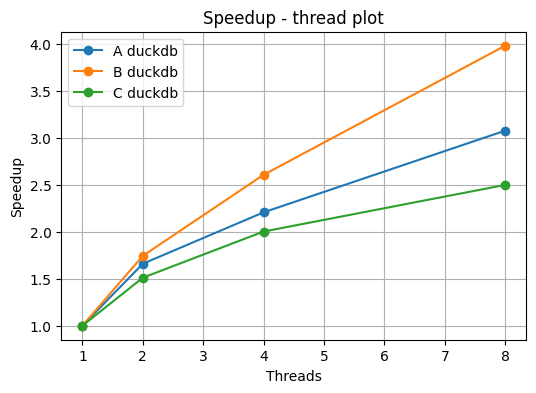

In [ ]:
threads = [1, 2, 4, 8]
queries_duckdb = {
    "A duckdb": query_A_duckdb,
    "B duckdb": query_B_duckdb,
    "C duckdb": query_C_duckdb,
}


def benchmark_scalability_duckdb(queries, threads):
    results = []
    for query_name, query_fn in queries.items():
        for td in threads:
            duckdb.sql(f"PRAGMA threads={td}")
            # warm-up
            query_fn()

            # benchmark
            t = measure_time(query_fn)

            results.append(
                {
                    "Threads": td,
                    "Query": query_name,
                    "Time [s]": t,
                }
            )

    return pd.DataFrame(results)


df_duckdb_result = benchmark_scalability_duckdb(queries_duckdb, threads)
print(df_duckdb_result)
plot_results(df_duckdb_result)

Polars - scalability test
Test implemented in other file - process has to be restarted to set new threads pool.

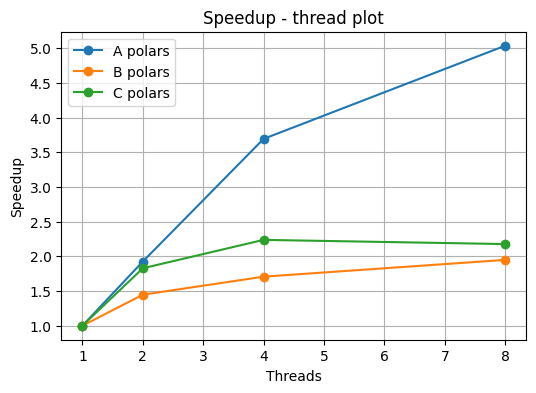

In [ ]:
df_polars_results = pd.read_csv("benchmark_polars.csv")

plot_results(df_polars_results)

Spark - scalability test

    Threads    Query   Time [s]
0         1  A spark   5.931790
1         1  B spark  36.515465
2         1  C spark   7.203541
3         2  A spark   5.971041
4         2  B spark  26.978781
5         2  C spark   9.713244
6         4  A spark   4.192679
7         4  B spark  20.456487
8         4  C spark   6.158111
9         8  A spark   5.345287
10        8  B spark  20.761994
11        8  C spark   6.148645


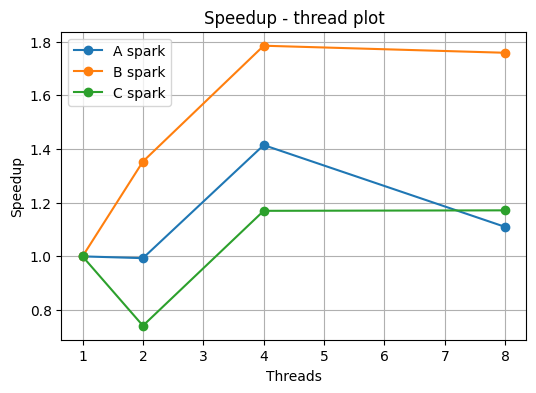

In [11]:
threads = [1, 2, 4, 8]


def measure_time(query):
    start = time.perf_counter()
    _ = query()
    elapsed = time.perf_counter() - start
    return elapsed


def benchmark_scalability_spark(threads):
    results = []

    for td in threads:
        try:
            spark.stop()
        except:
            pass
        spark = SparkSession.builder.master(f"local[{td}]").getOrCreate()

        spark.conf.set("spark.sql.shuffle.partitions", td)
        df_spark = spark.read.parquet(
            "/mnt/d/Studia - magisterskie/tbd-workshop/notebooks/social_media_data.parquet"
        ).repartition(td)
        df_spark_users = spark.read.parquet(
            "/mnt/d/Studia - magisterskie/tbd-workshop/notebooks/users.parquet"
        ).repartition(td)
        df_spark.createOrReplaceTempView("posts")
        df_spark_users.createOrReplaceTempView("users")

        def query_A_spark_repartitioned():
            return df_spark.groupBy("location").avg("likes").count()

        def query_B_spark_repartitioned():
            return spark.sql(
                """
                SELECT COUNT(*) FROM (SELECT *, AVG(likes) OVER ( PARTITION BY user_id
                    ORDER BY timestamp ROWS BETWEEN 2 PRECEDING AND CURRENT ROW ) AS avg_last_3 FROM posts)
                WHERE avg_last_3 > 5000"""
            ).collect()[0][0]

        def query_C_spark_repartitioned():
            return (
                df_spark.join(df_spark_users, on="user_id").where("age >= 25").count()
            )

        local_queries = {
            "A spark": query_A_spark_repartitioned,
            "B spark": query_B_spark_repartitioned,
            "C spark": query_C_spark_repartitioned,
        }
        for query_name, query_fn in local_queries.items():
            query_fn()

            # benchmark
            t = measure_time(query_fn)

            results.append(
                {
                    "Threads": td,
                    "Query": query_name,
                    "Time [s]": t,
                }
            )
        spark.stop()

    return pd.DataFrame(results)


df_spark_results = benchmark_scalability_spark(threads)
print(df_spark_results)
plot_results(df_spark_results)

### Task 2: Spark on Cluster

**Goal**: Compare Single Node performance vs. Spark on a Cluster.

**Instructions**:
1.  **Infrastructure**: Use the infrastructure from **Phase 1** (Google Dataproc). You may need to modify your Terraform code to adjust the cluster configuration (e.g., number of worker nodes).
2.  **Environment**: The easiest way to run this is via **Google Workbench** connected to your Dataproc cluster.
3.  **Upload Data**: Upload the generated `social_media_data.parquet` to HDFS or GCS.
    -   **Tip**: For better performance, consider **partitioning** the data (e.g., by `category` or `date`) when saving it to the distributed storage. This allows Spark to optimize reads.
4.  **Run Queries**: Run your PySpark queries from Task 1 on the cluster.
5.  **Scalability Test**: 
    -   Run the queries with different numbers of **worker nodes** (e.g., 2, 3, 4).
    -   You can achieve this by resizing the cluster (manually or via Terraform) or by configuring the number of executors in Spark.
6.  **Analyze**:
    -   How does the cluster performance compare to your local machine?
    -   Did adding more nodes/executors linearly improve performance?
    -   **Tip**: If Spark is slower than single-node engines, consider **increasing the dataset size** (e.g., generate 10M+ records or duplicate the data). Spark's overhead is significant for small data, and its true power appears when data exceeds single-node memory.

## Answers
### Infrastructure and environment
1. We used infrastructure from `Phase 1` in order to create Google Dataproc. We adjusted Terraform code in order to pass the number of worker nodes as a variable: 
  ```hcl
  variable "num_workers" {
    type        = number
    description = "Number of worker nodes"
  }
  ```
2. We uploaded the generated `social_media_data.parquet` and `users.parquet` to the bucket `tbd-2025z-304021-dataproc-temp`. `social_media_data.parquet` file contained 15M records.
3. We created `.ipynb` notebook prepared to run in the Dataproc environment. It can be found [there](benchmark_spark_dataproc.ipynb). Then we used `Vertex AI Workbench` in order to run it on the cluster:

![](workbench.png)

4. We ran the queries with different numbers of worker nodes - we chose `2`, `4` and `8`.

### Results
Results of running spark queries on Dataproc cluster can be found below: 


### Task 3: Execution Modes & Analysis

**Goal**: Deep dive into execution models and limitations.

**Instructions**:
1.  **Lazy vs. Eager vs. Streaming**:
    -   Use **Polars**. Compare the **Execution Time** and **Peak Memory** of:
        -   Eager execution (`read_parquet` -> filter).
        -   Lazy execution (`scan_parquet` -> filter -> `collect()`).
        -   Streaming execution (`scan_parquet` -> filter -> `collect(streaming=True)`).
2.  **Polars Limitations**:
    -   Identify a scenario where Polars might struggle compared to Spark (e.g., memory limits).
3.  **Decision Boundary**:
    -   Based on your findings, when would you recommend switching from a single-node tool (Polars/DuckDB) to a distributed engine (Spark)?

**Answers**:
1. Measuring time and memory for different execution types

In [ ]:
def query_eager_polars():
    return pl.read_parquet("social_media_data.parquet").filter(
        (pl.col("views") >= 10_000)
        & (pl.col("likes") >= 5_000)
        & (pl.col("timestamp") > pl.date(2024, 8, 8))
        & (pl.col("content").str.contains("fuck"))
        & (pl.col("location").is_in(["PL", "USA", "BR"]))
    )


def query_lazy_polars():
    return (
        pl.scan_parquet("social_media_data.parquet")
        .filter(
            (pl.col("views") >= 10_000)
            & (pl.col("likes") >= 5_000)
            & (pl.col("timestamp") > pl.date(2024, 8, 8))
            & (pl.col("content").str.contains("fuck"))
            & (pl.col("location").is_in(["PL", "USA", "BR"]))
        )
        .collect()
    )


def query_streaming_polars():
    return (
        pl.scan_parquet("social_media_data.parquet")
        .filter(
            (pl.col("views") >= 10_000)
            & (pl.col("likes") >= 5_000)
            & (pl.col("timestamp") > pl.date(2024, 8, 8))
            & (pl.col("content").str.contains("fuck"))
            & (pl.col("location").is_in(["PL", "USA", "BR"]))
        )
        .collect(engine="streaming")
    )


queries = {
    "Eager Polars": query_eager_polars,
    "Lazy Polars": query_lazy_polars,
    "Streaming Polars": query_streaming_polars,
}


def measure_time(query):
    start = time.perf_counter()
    _ = query()
    elapsed = time.perf_counter() - start
    return elapsed


def measure_peak_memory(query):
    return memory_usage(query, max_usage=True)


def benchmark(queries):
    results = []
    for query_name, query_fn in queries.items():

        # three query execution - first warm-up
        query_fn()

        # second for time benchmark
        t = measure_time(query_fn)

        # third for memory peak benchmark
        m = measure_peak_memory(query_fn)

        results.append({"Query": query_name, "Time [s]": t, "Memory peak [MiB]": m})

    return pd.DataFrame(results)


benchmark_results = benchmark(queries)
benchmark_results

,Query,Time [s],Memory peak [MiB]
0,Eager Polars,0.586394,4260.273438
1,Lazy Polars,0.000823,3939.101562
2,Streaming Polars,0.000764,3939.191406


2. Examining Polars limitations

While conducting benchmark tests is Task 1 one can see that for Query C Polars stays behind Spark. Query C is an example for a JOIN query on large sets. 

Polars is limited by single-node memory for stateful operations (joins, group-bys or sorts). Spark distributes this state across nodes via shuffle while Polars requires the full working set to fit in memory.

3. Tool decision

Polars or DuckDB as a single-node engines should be preferred as long as working state does not exceed the memory of one machine. These are the most efficient while executing operations that fits into machine memory. Spark as a distributed engine provides data redistribution and allows for state partitioning. It is developed for cases where single-node engines encounters memory bottleneck. In practical use, analysis on Big Data sets should be handled by technologies such as Spark.
